# IoT Intrusion Detection — Exploratory Data Analysis

### Objective
Explore class balance, feature distributions, and correlations in the cleaned
IoT network-flow data, using reproducible sampling for expensive plots. This
notebook is descriptive only — no learned transformation is fit here (that
happens, leakage-safely, in `03_Preprocessing.ipynb`).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_candidates = [Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts",
               Path.cwd().parent, Path.cwd().parent.parent / "scripts"]
_scripts_dir = next((c for c in _candidates if (c / "common.py").exists()), None)
if _scripts_dir is None:
    raise FileNotFoundError(f"Could not locate scripts/common.py from cwd={Path.cwd()}")
sys.path.insert(0, str(_scripts_dir))
from common import (ROOT, DATA_PATH, FIGURES_DIR, RANDOM_STATE, TARGET, ALTERNATE_TARGETS,
                     IDENTIFIER_COLS, TARGET_MAPPING, coerce_numeric_predictors)

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})
pd.set_option("display.max_columns", 100)


def save_figure(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved: figures/{name}")

## 1. Load and Clean a Working Copy

A local, lightweight clean copy (dtype fix + duplicate removal + target
mapping) is built here purely for exploration. The single authoritative,
leakage-safe preprocessing pipeline lives in notebook 03.

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
candidate_predictors = [c for c in df.columns if c not in [TARGET] + ALTERNATE_TARGETS + IDENTIFIER_COLS]
coerce_numeric_predictors(df, candidate_predictors)
df = df.drop_duplicates().reset_index(drop=True)
df["Label_encoded"] = df["Label"].map(TARGET_MAPPING)
print(f"Clean working copy: {df.shape[0]:,} rows x {df.shape[1]} columns")

Clean working copy: 461,696 rows x 87 columns


## 2. Class Distribution

The target is expected to be strongly imbalanced. This is the single most
important fact shaping every metric choice later in the project.

Label
Anomaly    423098
Normal      38598
Name: count, dtype: int64
Label
Anomaly    91.64
Normal      8.36
Name: proportion, dtype: float64
Saved: figures/class_distribution.png


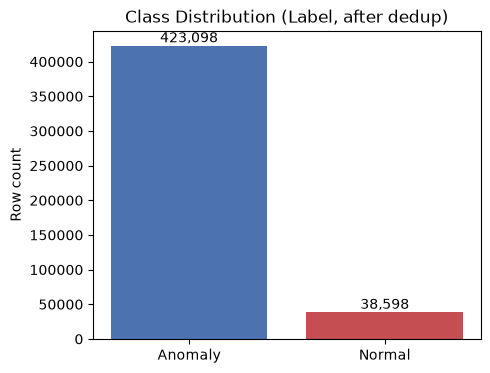

Saved: figures/class_percentage.png


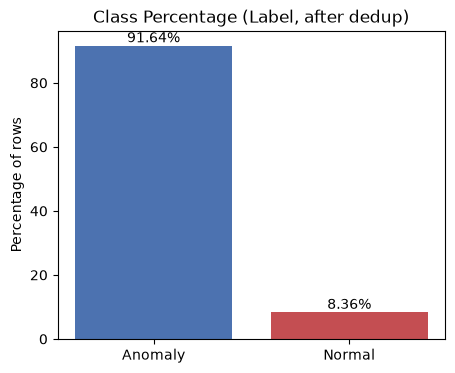

In [3]:
counts = df["Label"].value_counts()
pct = df["Label"].value_counts(normalize=True) * 100
print(counts)
print(pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts.index, counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_title("Class Distribution (Label, after dedup)")
ax.set_ylabel("Row count")
save_figure(fig, "class_distribution.png")
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(pct.index, pct.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(pct.values):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom")
ax.set_ylabel("Percentage of rows")
ax.set_title("Class Percentage (Label, after dedup)")
save_figure(fig, "class_percentage.png")
plt.show()

### Observation
Anomaly traffic dominates the cleaned dataset (~92%), confirming the need
for macro-averaged and per-class metrics (not raw accuracy) throughout the
rest of this project.

## 3. Informative Numeric Features for Visualization

Rather than plotting all ~70 numeric columns, a small, informative subset is
selected by absolute correlation with the encoded target — kept small and
readable per the project's efficiency guidance.

In [4]:
numeric_cols = [c for c in candidate_predictors if pd.api.types.is_numeric_dtype(df[c])]
corr_with_target_full = df[numeric_cols].corrwith(df["Label_encoded"]).abs().sort_values(ascending=False)
informative_features = corr_with_target_full.head(8).index.tolist()
print("Top correlated features with Label:")
print(corr_with_target_full.head(15))
print("\nSelected for visualization:", informative_features)

Top correlated features with Label:
Dst_Port            0.477500
Fwd_Pkt_Len_Std     0.326395
ACK_Flag_Cnt        0.298964
Src_Port            0.253356
Fwd_Pkt_Len_Max     0.222084
Protocol            0.220686
TotLen_Fwd_Pkts     0.187151
Subflow_Fwd_Byts    0.187151
Fwd_Seg_Size_Avg    0.176485
Fwd_Pkt_Len_Mean    0.176485
Pkt_Len_Std         0.174169
Bwd_Pkt_Len_Mean    0.165173
Bwd_Seg_Size_Avg    0.165173
Bwd_Pkt_Len_Min     0.161560
Pkt_Len_Max         0.160614
dtype: float64

Selected for visualization: ['Dst_Port', 'Fwd_Pkt_Len_Std', 'ACK_Flag_Cnt', 'Src_Port', 'Fwd_Pkt_Len_Max', 'Protocol', 'TotLen_Fwd_Pkts', 'Subflow_Fwd_Byts']


## 4. Feature Distributions (Sampled)

A reproducible 50,000-row sample keeps histogram rendering fast without
distorting the underlying distribution shape.

Saved: figures/selected_feature_distributions.png


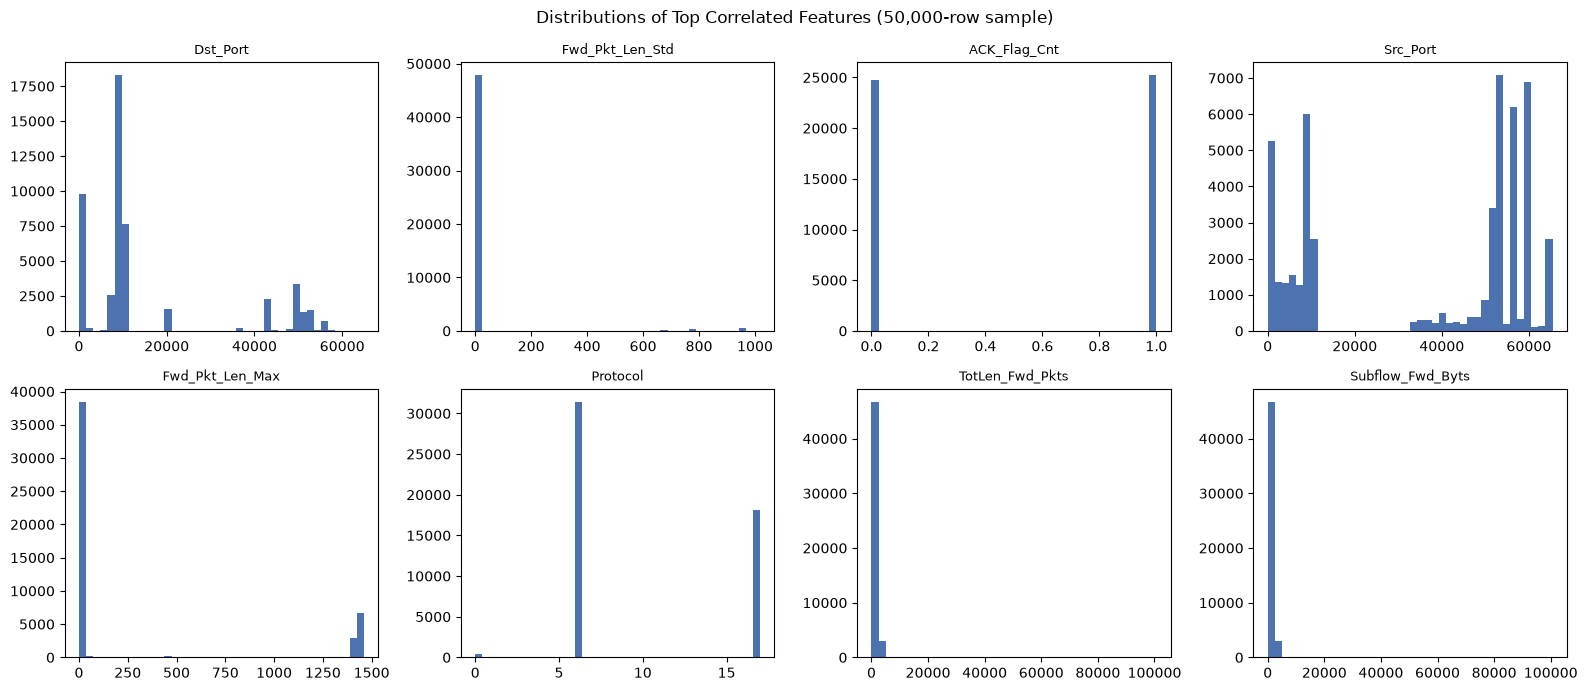

In [5]:
sample = df.sample(n=min(50000, len(df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), informative_features):
    ax.hist(sample[col].dropna(), bins=40, color="#4C72B0")
    ax.set_title(col, fontsize=9)
plt.suptitle("Distributions of Top Correlated Features (50,000-row sample)")
plt.tight_layout()
save_figure(fig, "selected_feature_distributions.png")
plt.show()

## 5. Normal vs. Anomaly Comparison

For the same informative features, side-by-side distributions by class
reveal which features visibly separate Normal from Anomaly traffic.

Saved: figures/normal_vs_anomaly_distributions.png


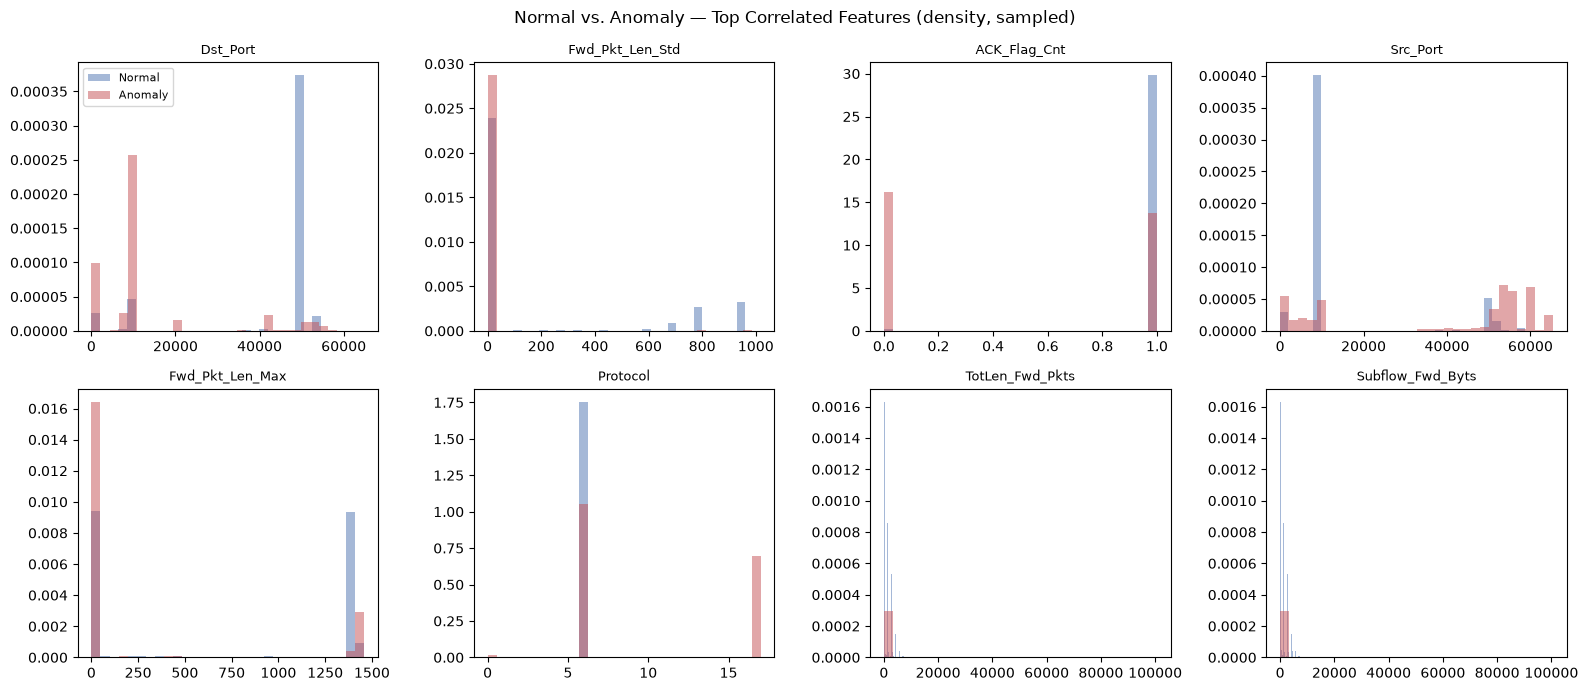

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), informative_features):
    for label, color in [("Normal", "#4C72B0"), ("Anomaly", "#C44E52")]:
        vals = sample.loc[sample["Label"] == label, col].dropna()
        ax.hist(vals, bins=30, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(col, fontsize=9)
axes.ravel()[0].legend(fontsize=8)
plt.suptitle("Normal vs. Anomaly — Top Correlated Features (density, sampled)")
plt.tight_layout()
save_figure(fig, "normal_vs_anomaly_distributions.png")
plt.show()

## 6. Boxplots (Selected Features)

Saved: figures/selected_boxplots.png


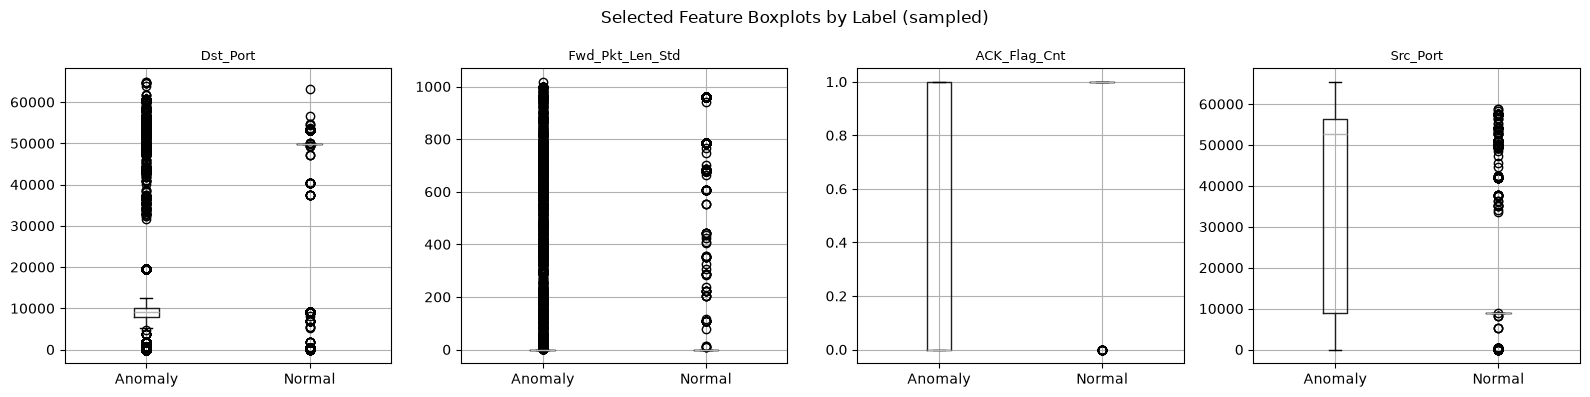

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes.ravel(), informative_features[:4]):
    sample.boxplot(column=col, by="Label", ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
plt.suptitle("Selected Feature Boxplots by Label (sampled)")
plt.tight_layout()
save_figure(fig, "selected_boxplots.png")
plt.show()

### Observation
Several features show visibly different spread/medians between Normal and
Anomaly traffic (and correspondingly wide outlier ranges) — this is exactly
the kind of signal the ANOVA test and tree-based importance scores in
notebook 04 are expected to pick up on quantitatively.

## 7. Correlation Analysis and Heatmap

                  Dst_Port  Fwd_Pkt_Len_Std  ACK_Flag_Cnt  Src_Port  Fwd_Pkt_Len_Max  Protocol  TotLen_Fwd_Pkts  Subflow_Fwd_Byts  Label_encoded
Dst_Port             1.000            0.235         0.424    -0.538            0.533    -0.256            0.336             0.336         -0.478
Fwd_Pkt_Len_Std      0.235            1.000         0.065    -0.133            0.377    -0.011            0.303             0.303         -0.326
ACK_Flag_Cnt         0.424            0.065         1.000    -0.160            0.149    -0.738            0.044             0.044         -0.299
Src_Port            -0.538           -0.133        -0.160     1.000           -0.374     0.530           -0.215            -0.215          0.253
Fwd_Pkt_Len_Max      0.533            0.377         0.149    -0.374            1.000     0.001            0.686             0.686         -0.222
Protocol            -0.256           -0.011        -0.738     0.530            0.001     1.000            0.069             0.069 

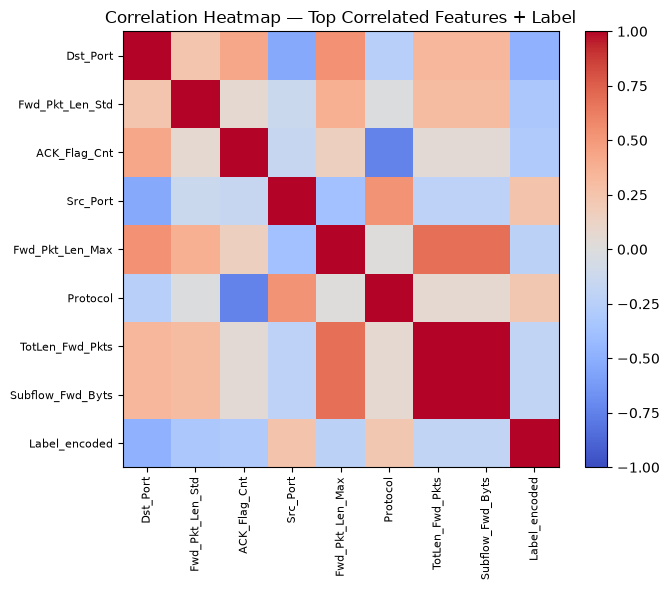

In [8]:
corr_cols = informative_features + ["Label_encoded"]
corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Correlation Heatmap — Top Correlated Features + Label")
plt.tight_layout()
save_figure(fig, "correlation_heatmap.png")
plt.show()

## 8. Target-Feature Relationships

Saved: figures/target_feature_relationships.png


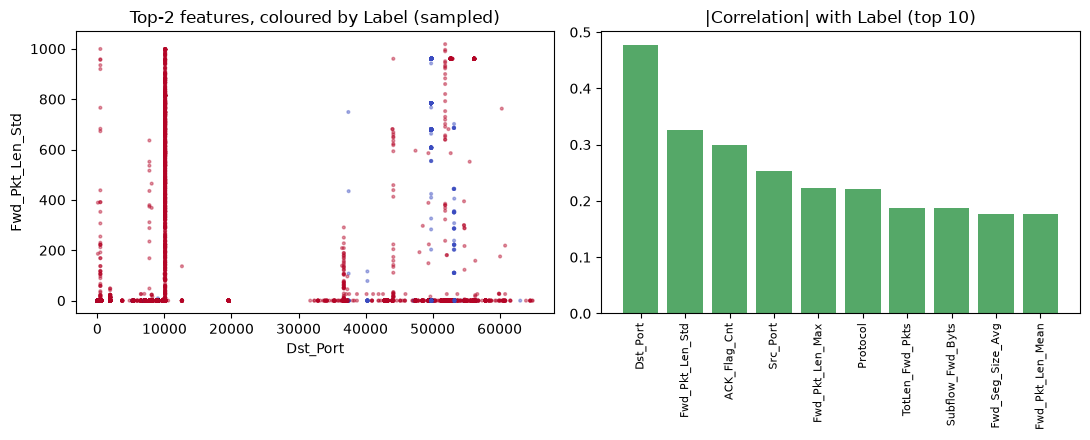

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(sample[informative_features[0]], sample[informative_features[1]],
                 c=sample["Label_encoded"], cmap="coolwarm", s=4, alpha=0.4)
axes[0].set_xlabel(informative_features[0]); axes[0].set_ylabel(informative_features[1])
axes[0].set_title("Top-2 features, coloured by Label (sampled)")

axes[1].bar(corr_with_target_full.head(10).index, corr_with_target_full.head(10).values, color="#55A868")
axes[1].set_xticklabels(corr_with_target_full.head(10).index, rotation=90, fontsize=8)
axes[1].set_title("|Correlation| with Label (top 10)")
plt.tight_layout()
save_figure(fig, "target_feature_relationships.png")
plt.show()

## Notebook Summary

In [10]:
from IPython.display import display, Markdown

summary_md = f"""
- Built a lightweight, local clean copy ({df.shape[0]:,} rows) for exploration only.
- Confirmed the target imbalance: {pct.round(2).to_dict()}.
- Selected {len(informative_features)} informative features by |correlation| with
  the target: {informative_features}.
- Produced and saved 7 report-quality figures to `figures/`: class distribution,
  class percentage, selected feature distributions, Normal-vs-Anomaly comparison,
  boxplots, correlation heatmap, and target-feature relationships.
- No model, imputer, or scaler was fit here — this notebook is purely descriptive.

**Next notebook (`03_Preprocessing.ipynb`)** builds the single authoritative,
leakage-safe preprocessing pipeline used by every model notebook after it.
"""
display(Markdown(summary_md))


- Built a lightweight, local clean copy (461,696 rows) for exploration only.
- Confirmed the target imbalance: {'Anomaly': 91.64, 'Normal': 8.36}.
- Selected 8 informative features by |correlation| with
  the target: ['Dst_Port', 'Fwd_Pkt_Len_Std', 'ACK_Flag_Cnt', 'Src_Port', 'Fwd_Pkt_Len_Max', 'Protocol', 'TotLen_Fwd_Pkts', 'Subflow_Fwd_Byts'].
- Produced and saved 7 report-quality figures to `figures/`: class distribution,
  class percentage, selected feature distributions, Normal-vs-Anomaly comparison,
  boxplots, correlation heatmap, and target-feature relationships.
- No model, imputer, or scaler was fit here — this notebook is purely descriptive.

**Next notebook (`03_Preprocessing.ipynb`)** builds the single authoritative,
leakage-safe preprocessing pipeline used by every model notebook after it.
